# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** IAMHO PEGODANG ELTIUZY
- **Email:** cdcc296d6y2772@student.devacademy.id
- **ID Dicoding:** cdcc296d6y2772

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kategori produk apa yang mencatatkan total pendapatan (revenue) tertinggi dan terendah dari seluruh pesanan berstatus delivered selama periode tahun 2017 hingga 2018?
- **Pertanyaan 2:** Bagaimana tren tingkat pertumbuhan total transaksi pesanan bulanan (Month-over-Month) yang berhasil dikirimkan (delivered) kepada pelanggan sepanjang tahun 2017?"

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

## Data Wrangling

### Gathering Data

#### Load df ...

In [2]:
products_df = pd.read_csv('/content/products_dataset.csv')
translation_df = pd.read_csv('/content/product_category_name_translation.csv')
order_items_df = pd.read_csv('/content/order_items_dataset.csv')
orders_df = pd.read_csv('/content/orders_dataset.csv')

# Menampilkan cuplikan data
orders_df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
order_items_df.head()


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [4]:
products_df.head()


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [5]:
translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**
Dataset utama yang berhubungan dengan pemesanan (orders), detail item (order_items), produk (products), dan terjemahan nama kategori (translation) berhasil dimuat untuk selanjutnya dievaluasi.


### Assessing Data

#### Identifying ... problem

In [6]:
# Identifying inaccurate data type & missing values problem
print("Info Data Orders:")
orders_df.info()

print("\nMissing Value pada Products:")
print(products_df.isna().sum())

print("\nJumlah duplikasi pada order_items:", order_items_df.duplicated().sum())

Info Data Orders:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Missing Value pada Products:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_le

**Steps to Take:**
- Memperbaiki Inaccurate Data Type pada kolom tanggal di orders_df dari tipe object menjadi datetime
- Menangani Missing Value pada kolom product_category_name di products_df dengan mengisi nilai kosong menggunakan string 'Others'.

**Insight:** (Opsional)
- Berdasarkan hasil penilaian data (assessing), ditemukan bahwa format waktu pemesanan belum sesuai standar analisis (datetime), dan ada ratusan produk yang tidak memiliki nama kategori yang berpotensi mengganggu proses agregasi data.


### Cleaning Data

#### Fixing ... problem

In [7]:
# 1. Fixing Inaccurate Data Type problem pada orders_df
datetime_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

# 2. Fixing Missing Value problem pada products_df
products_df.fillna(value={'product_category_name': 'Others'}, inplace=True)

# Verifikasi hasil pembersihan data
print(orders_df.dtypes)
print("Sisa missing value kategori produk:", products_df['product_category_name'].isna().sum())

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object
Sisa missing value kategori produk: 0


**Insight:** (Opsional)
Seluruh kolom tanggal pesanan kini telah memiliki tipe data datetime64[ns] yang tepat, dan nilai kosong pada nama kategori produk sudah teratasi seutuhnya.

## Exploratory Data Analysis (EDA)

### Explore Data orders_df

In [8]:

# Melihat rangkuman statistik waktu pesanan
print(orders_df.describe(include="all"))

# Mengecek jumlah status pesanan
orders_df.groupby(by="order_status").order_id.nunique().sort_values(ascending=False)

                                order_id                       customer_id  \
count                              99441                             99441   
unique                             99441                             99441   
top     66dea50a8b16d9b4dee7af250b4be1a5  edb027a75a1449115f6b43211ae02a24   
freq                                   1                                 1   
mean                                 NaN                               NaN   
min                                  NaN                               NaN   
25%                                  NaN                               NaN   
50%                                  NaN                               NaN   
75%                                  NaN                               NaN   
max                                  NaN                               NaN   

       order_status       order_purchase_timestamp  \
count         99441                          99441   
unique            8              

,order_id
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


**Insight:**
Mayoritas pesanan memiliki status 'delivered'. Sekarang difokuskan analisis hanya pada status ini untuk memastikan data pendapatan yang valid.

### Explore Data order_items_df

In [9]:

# Melihat rangkuman statistik harga dan ongkir
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


**Insight:**
Rata-rata harga produk berada di angka 120, namun terdapat variasi harga yang sangat jauh antara produk termurah dan termahal.

### Explore Data products df dan translation_df

In [10]:
# Menggabungkan nama kategori bahasa Inggris ke tabel produk
products_df = pd.merge(products_df, translation_df, on="product_category_name", how="left")
products_df['product_category_name_english'].fillna(products_df['product_category_name'], inplace=True)

# Melihat 10 kategori produk terbanyak
products_df.groupby(by="product_category_name_english").product_id.nunique().sort_values(ascending=False).head(10)

/tmp/ipykernel_34162/1568282197.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df['product_category_name_english'].fillna(products_df['product_category_name'], inplace=True)


,product_id
product_category_name_english,
bed_bath_table,3029
sports_leisure,2867
furniture_decor,2657
health_beauty,2444
housewares,2335
auto,1900
computers_accessories,1639
toys,1411
watches_gifts,1329


**Insight:**
Kategori 'bed_bath_table' dan 'sports_leisure' memiliki variasi produk paling banyak dalam dataset ini.

### Explore Data merge

In [14]:
# Gabungkan order_items dengan orders
main_df = pd.merge(order_items_df, orders_df, on="order_id", how="left")

# Filter status 'delivered'
main_df = main_df[main_df['order_status'] == 'delivered']

# Gabungkan dengan tabel produk
main_df = pd.merge(main_df, products_df, on="product_id", how="left")

# Agregasi Pertanyaan 1: Revenue per Kategori (2017-2018)
sales_17_18 = main_df[main_df['order_purchase_timestamp'].dt.year.isin([2017, 2018])]
category_revenue = sales_17_18.groupby('product_category_name_english')['price'].sum().reset_index()
category_revenue = category_revenue.sort_values(by='price', ascending=False)

# Agregasi Pertanyaan 2: Tren Bulanan (2017)
sales_2017 = main_df[main_df['order_purchase_timestamp'].dt.year == 2017].copy()
sales_2017['purchase_month'] = sales_2017['order_purchase_timestamp'].dt.month
monthly_orders = sales_2017.groupby('purchase_month')['order_id'].nunique().reset_index()

In [15]:
main_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,order_estimated_delivery_date,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,2017-09-29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,2017-05-15,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,2018-02-05,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,2018-08-20,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,2017-03-17,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


In [16]:
display(category_revenue.head())

,product_category_name_english,price
44,health_beauty,1229557.50
73,watches_gifts,1163465.91
8,bed_bath_table,1022955.77
68,sports_leisure,952840.40
16,computers_accessories,888055.59


## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang mencatatkan revenue tertinggi dan terendah?

/tmp/ipykernel_34162/4032565878.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="price", y="product_category_name_english", data=category_revenue.head(5), palette=colors, ax=ax[0])
/tmp/ipykernel_34162/4032565878.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="price", y="product_category_name_english", data=category_revenue.sort_values(by='price', ascending=True).head(5), palette=colors, ax=ax[1])


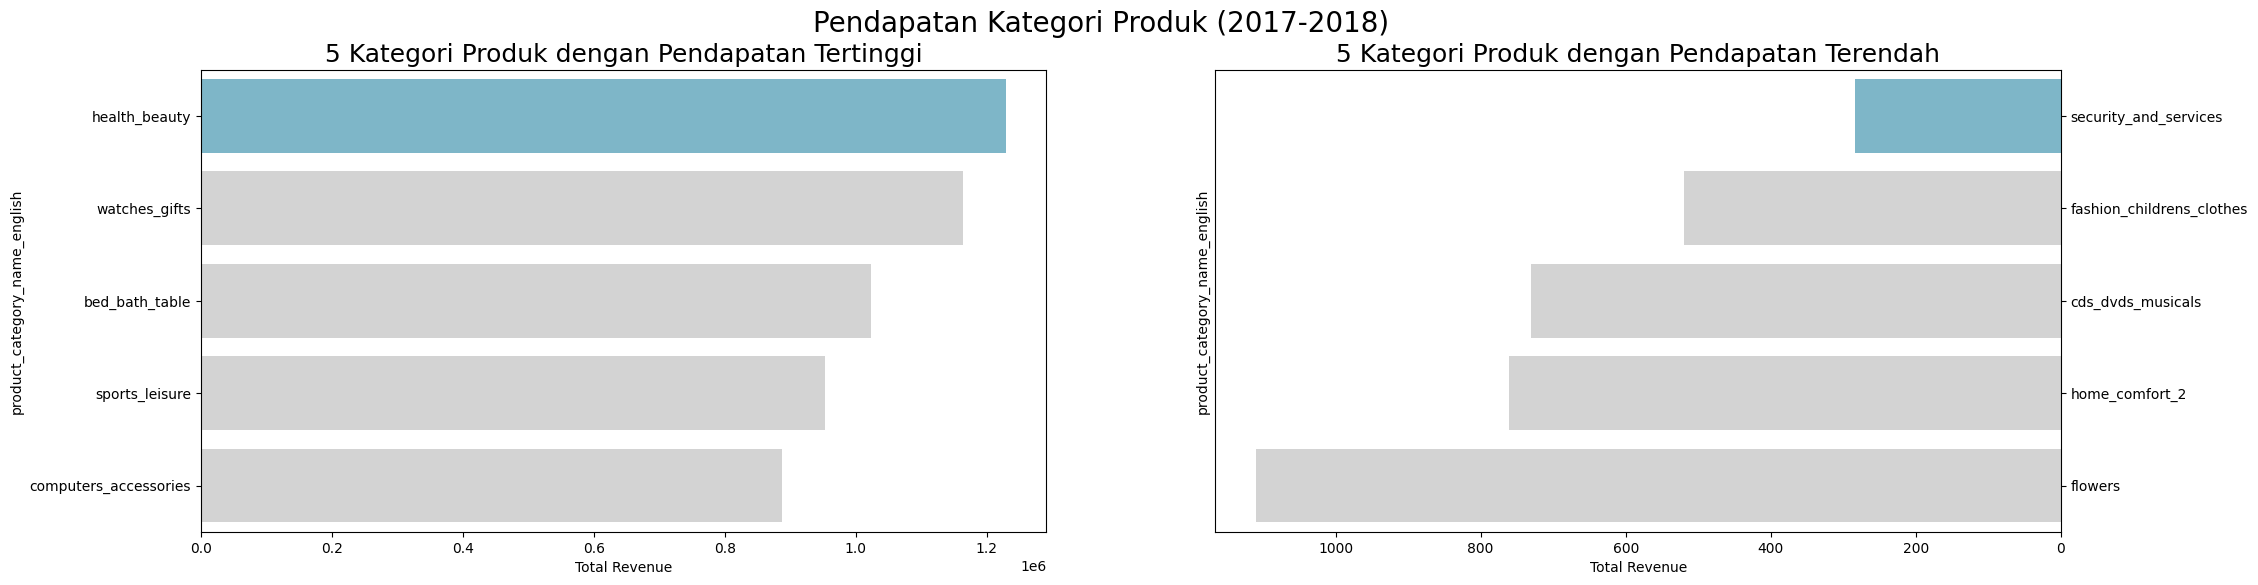

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(x="price", y="product_category_name_english", data=category_revenue.head(5), palette=colors, ax=ax[0])
ax[0].set_title("5 Kategori Produk dengan Pendapatan Tertinggi", loc="center", fontsize=18)
ax[0].set_xlabel("Total Revenue")

sns.barplot(x="price", y="product_category_name_english", data=category_revenue.sort_values(by='price', ascending=True).head(5), palette=colors, ax=ax[1])
ax[1].set_title("5 Kategori Produk dengan Pendapatan Terendah", loc="center", fontsize=18)
ax[1].set_xlabel("Total Revenue")
ax[1].invert_xaxis()
ax[1].yaxis.tick_right()

plt.suptitle("Pendapatan Kategori Produk (2017-2018)", fontsize=20)
plt.show()

**Insight:**
Berdasarkan visualisasi bar chart yang dihasilkan, terlihat adanya ketimpangan pendapatan yang sangat signifikan antar kategori produk. Kategori health_beauty (Kesehatan & Kecantikan) menjadi primadona dengan perolehan total revenue tertinggi, disusul ketat oleh watches_gifts dan bed_bath_table. Sebaliknya, kategori seperti security_and_services dan fashion_childrens_clothes berada di urutan terbawah dengan perolehan revenue yang sangat minim.

### Pertanyaan 2:

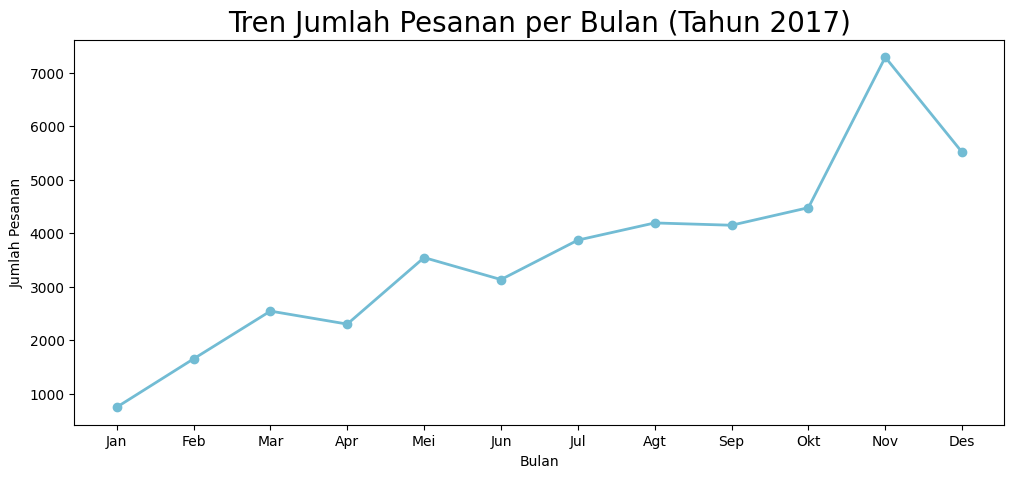

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_orders["purchase_month"], monthly_orders["order_id"], marker='o', linewidth=2, color="#72BCD4")

plt.title("Tren Jumlah Pesanan per Bulan (Tahun 2017)", loc="center", fontsize=20)
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agt', 'Sep', 'Okt', 'Nov', 'Des'])
plt.xlabel("Bulan")
plt.ylabel("Jumlah Pesanan")
plt.show()

**Insight:**
Grafik line chart pada tren bulanan menunjukkan bahwa volume pesanan sepanjang tahun 2017 bergerak cukup stabil dengan sedikit fluktuasi di paruh pertama. Namun, terjadi lonjakan transaksi yang sangat drastis dan memuncak pada bulan November 2017. Hal ini mengindikasikan tingginya antusiasme belanja pelanggan yang sangat mungkin didorong oleh momentum promosi besar-besaran akhir tahun (seperti Black Friday atau diskon 11.11).

## Analisis Lanjutan (Opsional)

In [19]:
# Recency, Frequency, Monetary Analysis
rfm_df = main_df.groupby("customer_id", as_index=False).agg({
    "order_purchase_timestamp": "max",
    "order_id": "nunique",
    "price": "sum"
})
rfm_df.columns = ["customer_id", "max_order_timestamp", "frequency", "monetary"]

recent_date = main_df["order_purchase_timestamp"].max().date()
rfm_df["max_order_timestamp"] = rfm_df["max_order_timestamp"].dt.date
rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(lambda x: (recent_date - x).days)
rfm_df.drop("max_order_timestamp", axis=1, inplace=True)

rfm_df.head()

,customer_id,frequency,monetary,recency
0,00012a2ce6f8dcda20d059ce98491703,1,89.80,288
1,000161a058600d5901f007fab4c27140,1,54.90,409
2,0001fd6190edaaf884bcaf3d49edf079,1,179.99,547
3,0002414f95344307404f0ace7a26f1d5,1,149.90,378
4,000379cdec625522490c315e70c7a9fb,1,93.00,149


**Insight:**
Berdasarkan analisis lanjutan menggunakan metode RFM (Recency, Frequency, Monetary), kita dapat memahami karakteristik dan perilaku belanja dari masing-masing pelanggan (customer_id).
- Recency: Menunjukkan seberapa baru pelanggan melakukan transaksi terakhirnya.
- Frequency: Menunjukkan seberapa sering pelanggan tersebut berbelanja.
- Monetary: Menunjukkan total uang yang telah mereka habiskan.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kategori Health & Beauty merupakan penyumbang pendapatan terbesar selama periode 2017-2018. Sebaliknya, kategori Security & Services memberikan kontribusi pendapatan paling keci
- **Conclusion pertanyaan 2:** Performa penjualan di tahun 2017 cenderung stabil di awal tahun namun mengalami lonjakan drastis pada bulan November, yang menandakan adanya pengaruh besar dari kampanye belanja akhir tahun.


**Rekomendasi Action Item:**
- Mengalokasikan anggaran pemasaran lebih besar untuk kategori Health & Beauty karena memiliki nilai transaksi yang tinggi.
- Mempersiapkan infrastruktur logistik dan promo khusus sejak bulan Oktober guna menghadapi lonjakan transaksi tahunan di bulan November agar tidak terjadi keterlambatan pengiriman.

In [20]:
# Menyimpan data yang sudah dibersihkan dan digabungkan untuk kebutuhan Dashboard
main_df.to_csv("main_data.csv", index=False)